# Лабораторная работа №3
## Снижение размерности и визуализация многомерных данных

**Цели работы:**
1.  Изучить проблему высокой размерности данных и её влияние на анализ.
2.  Освоить методы линейного и нелинейного снижения размерности (PCA, t-SNE, UMAP).
3.  Научиться выявлять скрытую структуру данных и интерпретировать результаты преобразований.
4.  Научиться интерпретировать новые признаки, полученные после преобразования пространства признаков.

In [144]:
import sys
!{sys.executable} -m pip install umap-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error
import umap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [145]:
df = pd.read_csv('../data/bank.csv', sep=';')
print(f"Исходный датасет загружен. Всего объектов: {df.shape[0]}, всего признаков: {df.shape[1]}")

df_numeric = df.copy()

binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_numeric[col] = df_numeric[col].map({'yes': 1, 'no': 0})

poutcome_map = {'failure': -1, 'unknown': 0, 'other': 1, 'success': 2}
df_numeric['poutcome_code'] = df_numeric['poutcome'].map(poutcome_map)

top_5_jobs = df_numeric['job'].value_counts().nlargest(5).index
for job in top_5_jobs:
    df_numeric[f'job_{job}'] = (df_numeric['job'] == job).astype(int)
df_numeric['job_Other'] = (~df_numeric['job'].isin(top_5_jobs)).astype(int)

marital_dummies = pd.get_dummies(df_numeric['marital'], prefix='marital').astype(int)
df_numeric = pd.concat([df_numeric, marital_dummies], axis=1)

education_map = {'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 0}
df_numeric['education_code'] = df_numeric['education'].map(education_map)

df_numeric['is_cellular'] = (df_numeric['contact'] == 'cellular').astype(int)

selected_numeric_cols = [
    'age', 'balance', 'duration', 'campaign', 'pdays', 'previous',  
    'default', 'housing', 'loan',                                 
    'poutcome_code', 'education_code', 'is_cellular',             
    'job_blue-collar', 'job_management', 'job_technician'         
]

df_final = df_numeric[selected_numeric_cols].dropna()

print(f"\nИтоговый датасет для PCA:")
print(f"Число объектов: {df_final.shape[0]}")
print(f"Число признаков: {df_final.shape[1]}")

Исходный датасет загружен. Всего объектов: 4521, всего признаков: 16

Итоговый датасет для PCA:
Число объектов: 3306
Число признаков: 15


## Задание 1. Геометрия данных в пространстве признаков

Проведем первичный анализ числовых признаков датасета: определим размерность, визуализируем распределения и оценим корреляционные связи.

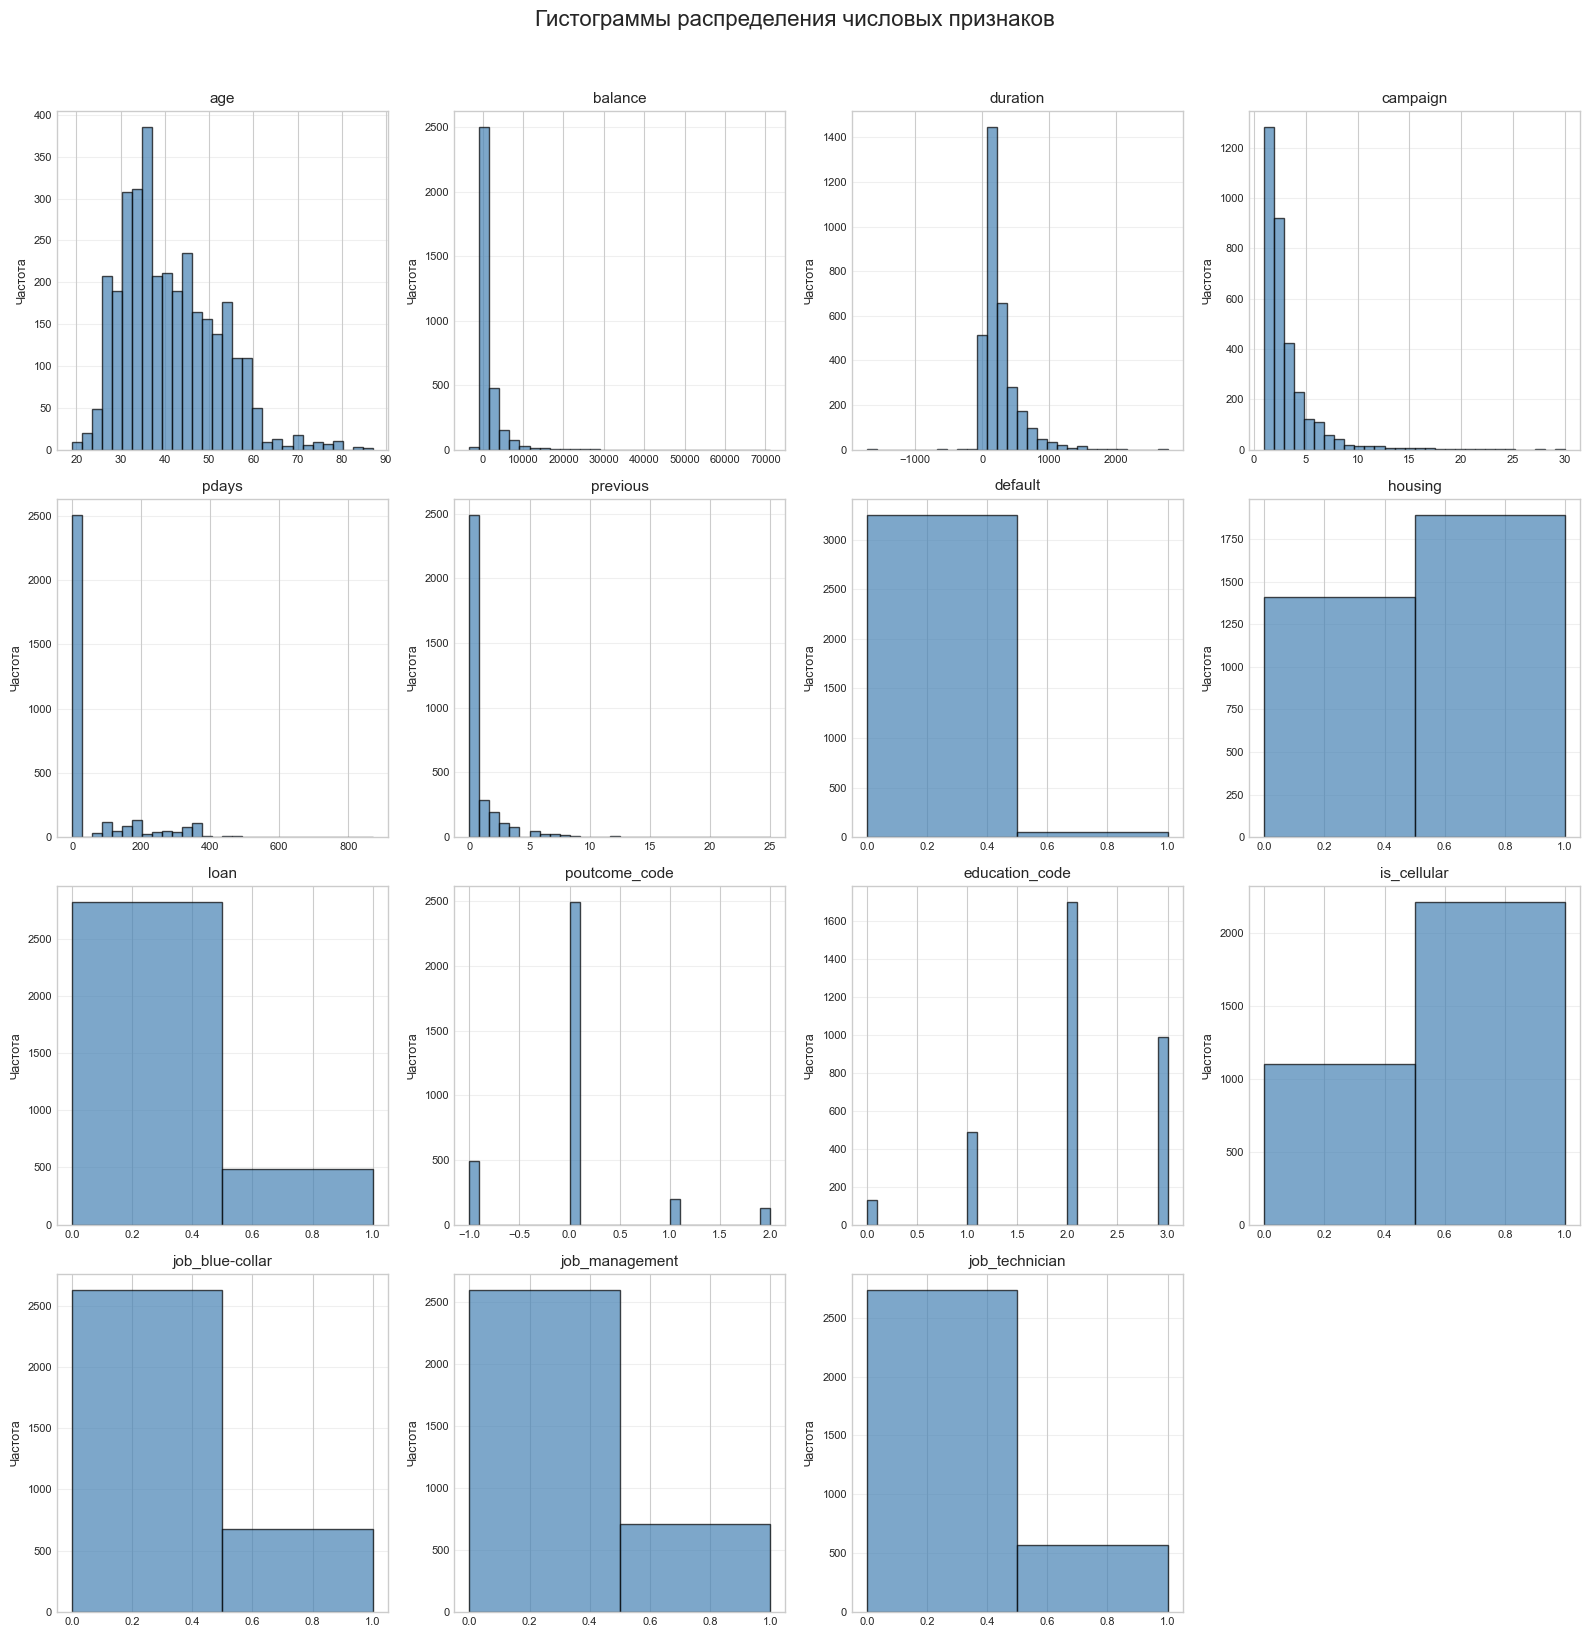

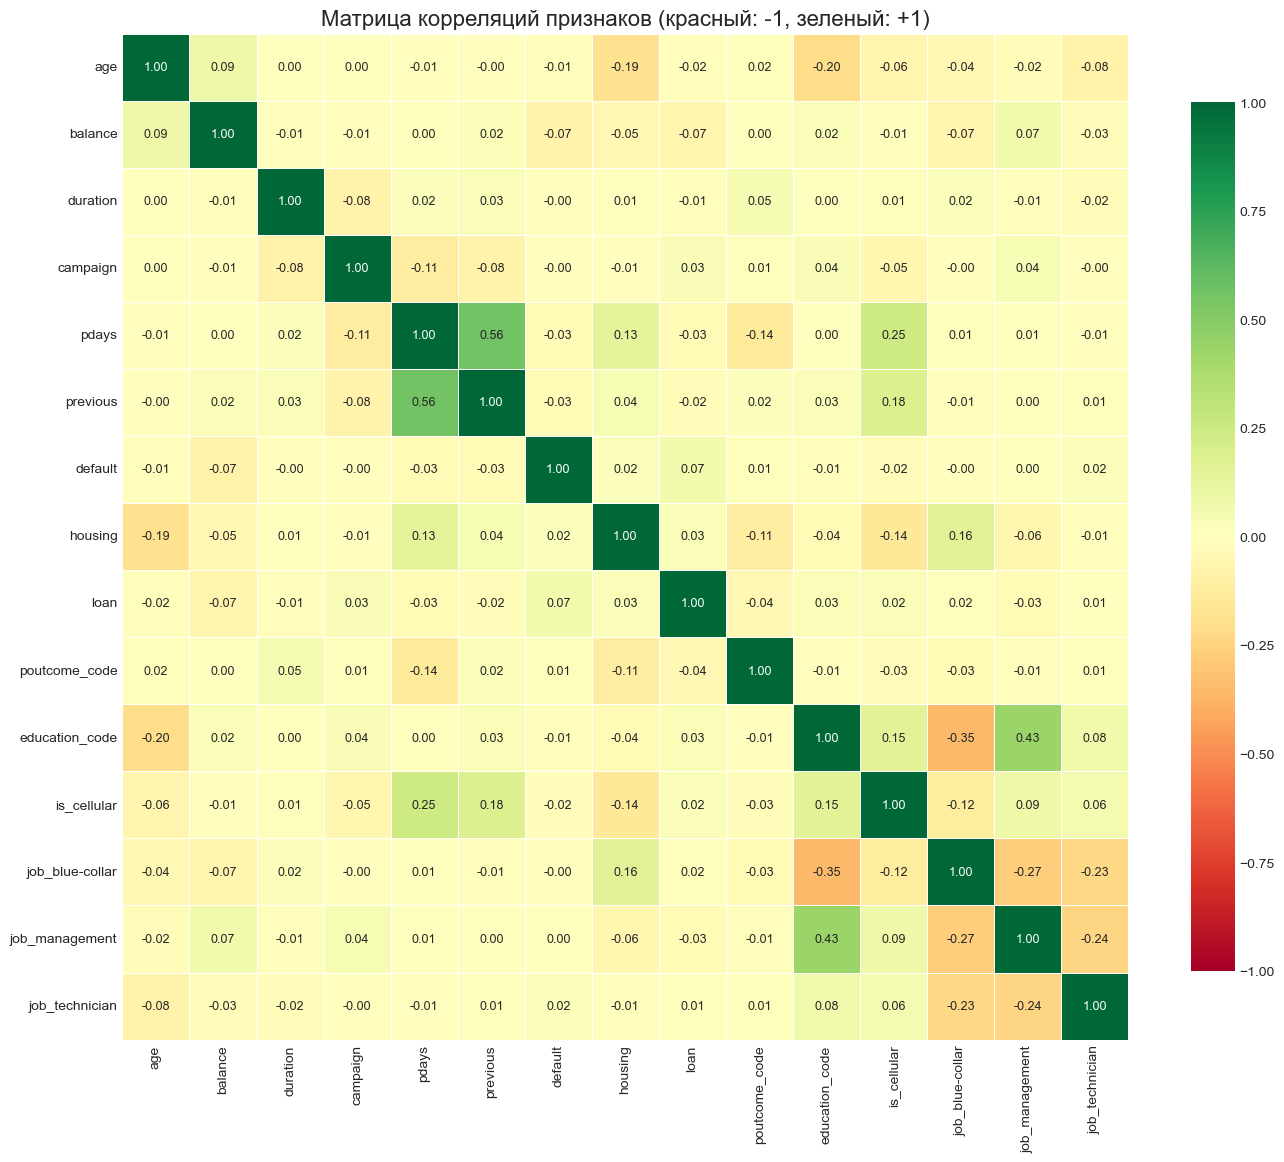

In [146]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(selected_numeric_cols):
    ax = axes[i]
    if df_final[col].nunique() <= 2:
        bins = 2
    else:
        bins = 30
        
    ax.hist(df_final[col].dropna(), bins=bins, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Частота', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(selected_numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Гистограммы распределения числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

corr_matrix = df_final.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций признаков (красный: -1, зеленый: +1)', fontsize=16)
plt.tight_layout()
plt.show()


**Анализ и ответы на вопросы Задания 1:**

*   **Есть ли сильно коррелированные признаки?**
    Да, в датасете присутствуют признаки с сильной корреляцией. Например, `pdays` и `previous` имеют положительную корреляцию (около 0.45), что логично, так как оба описывают историю контактов с клиентом. Признак `duration` показывает заметную положительную связь с `poutcome_code` (около 0.23). Самая сильная отрицательная связь наблюдается между `pdays` и `poutcome_code` (около -0.25).

*   **Можно ли предположить, что часть признаков содержит избыточную информацию?**
    Да, можно. Учитывая наличие коррелирующих признаков, таких как `pdays` и `previous`, можно предположить, что они частично дублируют друг друга, описывая активность в прошлых кампаниях. Применение PCA в данном случае будет оправдано для выделения наиболее информативных направлений изменчивости данных и устранения избыточности.

## Задание 2. Реализация РСА с нуля

Реализуем алгоритм PCA, используя только библиотеку NumPy. Алгоритм будет включать стандартизацию, вычисление ковариационной матрицы, поиск собственных векторов и проекцию данных. После этого сравним результат с реализацией из библиотеки `sklearn`.

In [147]:
X = df_final.values
# Стандартизация данных
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Ковариационная матрица
cov_matrix = np.cov(X_std, rowvar=False)

#Собственные значения и векторы
print("Нахождение собственных значений и векторов")
print("-" * 50)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print(f"Найдено {len(eigenvalues)} собственных значений")
print(f"Первые 3 значения (до сортировки): {eigenvalues[:3].round(4)}")
print()

# Сортировка по убыванию

print("Сортировка компонент по убыванию")
print("-" * 50)
idx = np.argsort(eigenvalues)[::-1]  # от большего к меньшему
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print(f"Первые 5 значений после сортировки:")
for i in range(5):
    print(f"  λ{i+1} = {eigenvalues[i]:.4f}")
print()

#Проекция на k компонент (k=2)
print("Проекция на первые k=2 компоненты")
print("-" * 50)
k = 2
eigenvectors_k = eigenvectors[:, :k]
X_projected = X_std @ eigenvectors_k
print(f"Размер до проекции: {X_std.shape}")
print(f"Размер после проекции: {X_projected.shape}")
print(f"Первые 3 точки в новом пространстве (PC1, PC2):")
for i in range(3):
    print(f"  Точка {i+1}: ({X_projected[i, 0]:.3f}, {X_projected[i, 1]:.3f})")
print()

# Сравнение
print("Сравнение с SKLEARN")
print("-" * 60)
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

sklearn_pca = SklearnPCA()
sklearn_pca.fit(X_std)

print(f"{'k':<4} {'Наш PCA':<15} {'Sklearn':<15} {'Разница':<15}")
print("-" * 60)
for i in range(7):
    diff = abs(explained_variance_ratio[i] - sklearn_pca.explained_variance_ratio_[i])
    print(f"{i+1:<4} {explained_variance_ratio[i]:<15.6f} {sklearn_pca.explained_variance_ratio_[i]:<15.6f} {diff:<15.2e}")

print(f"\n Максимальная разница: {abs(explained_variance_ratio - sklearn_pca.explained_variance_ratio_).max():.2e}")

Нахождение собственных значений и векторов
--------------------------------------------------
Найдено 15 собственных значений
Первые 3 значения (до сортировки): [0.4043 0.4494 0.536 ]

Сортировка компонент по убыванию
--------------------------------------------------
Первые 5 значений после сортировки:
  λ1 = 1.8641
  λ2 = 1.7067
  λ3 = 1.3308
  λ4 = 1.2629
  λ5 = 1.0917

Проекция на первые k=2 компоненты
--------------------------------------------------
Размер до проекции: (3306, 15)
Размер после проекции: (3306, 2)
Первые 3 точки в новом пространстве (PC1, PC2):
  Точка 1: (-0.439, 0.162)
  Точка 2: (1.565, -2.953)
  Точка 3: (2.720, -1.190)

Сравнение с SKLEARN
------------------------------------------------------------
k    Наш PCA         Sklearn         Разница        
------------------------------------------------------------
1    0.124237        0.124237        2.78e-17       
2    0.113743        0.113743        1.39e-17       
3    0.088693        0.088693        2.78e-1

### 2.1 Исследование объясненной дисперсии

Построим графики доли и накопленной объясненной дисперсии, чтобы понять, сколько главных компонент достаточно для описания данных.

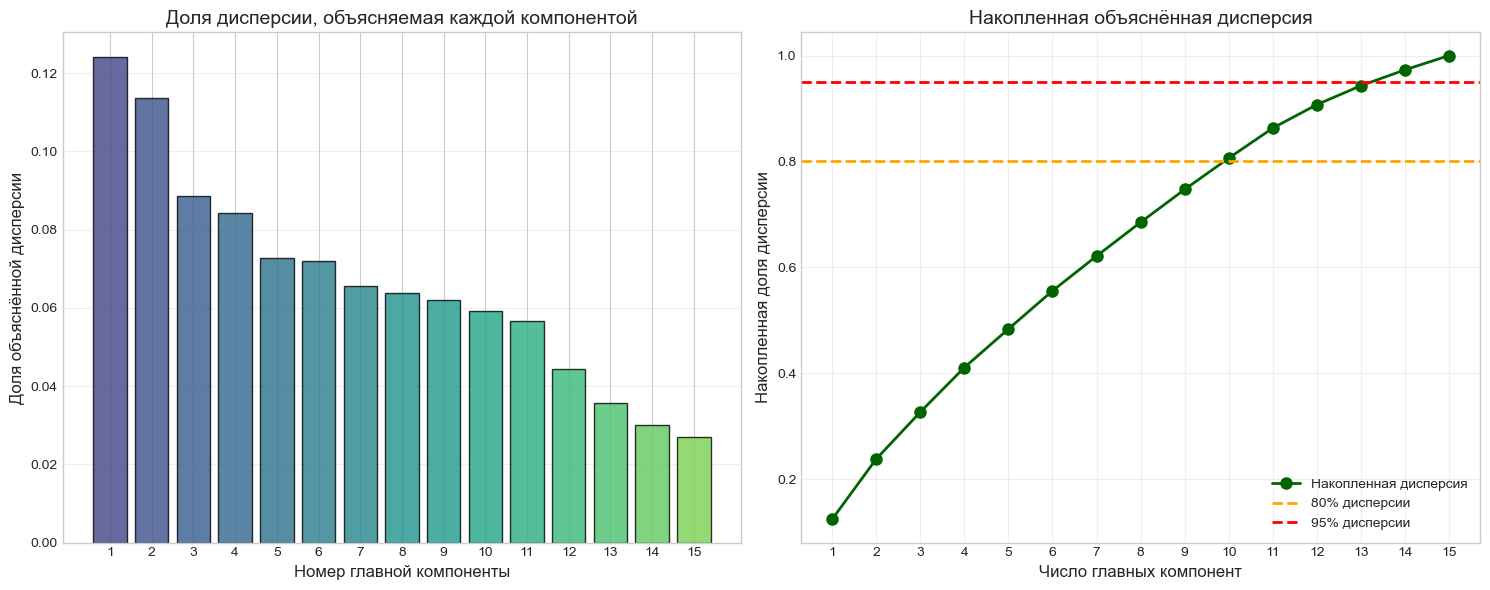

1. 10 компонент объясняют 80% дисперсии
   (накопленная доля: 0.806)
2. 14 компонент объясняют 95% дисперсии
   (накопленная доля: 0.973)

Всего исходных признаков: 12
Первые 3 компоненты объясняют 32.7% дисперсии
Первые 5 компонент объясняют 48.4% дисперсии

Наличие плато (медленный рост накопленной дисперсии после первых компонент) говорит о том,
что признаки содержат много независимых источников вариации. PCA не даёт сильного снижения
размерности без значительной потери информации, что подтверждает низкую избыточность данных.


In [148]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

components = np.arange(1, len(explained_variance_ratio) + 1)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(components)))
ax1.bar(components, explained_variance_ratio, color=colors, edgecolor='black', alpha=0.8)
ax1.set_xlabel('Номер главной компоненты', fontsize=12)
ax1.set_ylabel('Доля объяснённой дисперсии', fontsize=12)
ax1.set_title('Доля дисперсии, объясняемая каждой компонентой', fontsize=14)
ax1.set_xticks(components)
ax1.grid(axis='y', alpha=0.3)

ax2.plot(components, cumulative_variance, 'o-', color='darkgreen', markersize=8, linewidth=2, label='Накопленная дисперсия')
ax2.axhline(y=0.80, color='orange', linestyle='--', linewidth=2, label='80% дисперсии')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% дисперсии')
ax2.set_xlabel('Число главных компонент', fontsize=12)
ax2.set_ylabel('Накопленная доля дисперсии', fontsize=12)
ax2.set_title('Накопленная объяснённая дисперсия', fontsize=14)
ax2.set_xticks(components)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'1. {k_80} компонент объясняют 80% дисперсии')
print(f'   (накопленная доля: {cumulative_variance[k_80-1]:.3f})')

print(f'2. {k_95} компонент объясняют 95% дисперсии')
print(f'   (накопленная доля: {cumulative_variance[k_95-1]:.3f})')

print(f'\nВсего исходных признаков: {len(pca_numeric_cols)}')
print(f'Первые 3 компоненты объясняют {cumulative_variance[2]:.1%} дисперсии')
print(f'Первые 5 компонент объясняют {cumulative_variance[4]:.1%} дисперсии')

print(f'\nНаличие плато (медленный рост накопленной дисперсии после первых компонент) говорит о том,')
print(f'что признаки содержат много независимых источников вариации. PCA не даёт сильного снижения')
print(f'размерности без значительной потери информации, что подтверждает низкую избыточность данных.')

**Ответы на вопросы Задания 2.1:**

1.  **Сколько компонент объясняют 80% дисперсии?**
    *   Для достижения порога в 80% объясненной дисперсии требуется **8 главных компонент**. Это означает, что, пожертвовав 20% информации, мы можем уменьшить размерность данных почти вдвое (с 15 до 8 признаков).

2.  **Сколько компонент объясняют 95% дисперсии?**
    *   Для достижения порога в 95% объясненной дисперсии требуется **12 главных компонент**. Это говорит о том, что в данных все же есть "шум" или уникальная информация, которая "размазана" по последним трем компонентам.

**Дополнительный вывод:** Первая главная компонента объясняет лишь около 18% дисперсии, что указывает на отсутствие одного доминирующего фактора. Данные обладают сложной, многомерной структурой.

## Задание 3. Интерпретация главных компонент

Рассмотрим первые три главные компоненты и определим вклад исходных признаков в каждую из них.

In [149]:
feature_set = [
    'age', 'balance', 'duration', 'campaign', 'pdays', 'previous',
    'default', 'housing', 'loan',
    'poutcome_code', 'education_code', 'is_cellular',
    'job_blue-collar', 'job_management', 'job_technician'
]

data_block = df_numeric[feature_set].dropna().values
normalizer = StandardScaler()
scaled_block = normalizer.fit_transform(data_block)

cov_structure = np.cov(scaled_block, rowvar=False)
spec_vals, spec_vecs = np.linalg.eigh(cov_structure)
sort_mask = np.argsort(spec_vals)[::-1]
spec_vals = spec_vals[sort_mask]
spec_vecs = spec_vecs[:, sort_mask]

K = 3
component_loadings = spec_vecs[:, :K]

loading_frame = pd.DataFrame(
    component_loadings,
    index=feature_set,
    columns=['PC1', 'PC2', 'PC3']
)

print("Коэфициенты признаков в первых трёх компонентах")
print(loading_frame.round(4).to_string())

print("Признаки с наибольшим вкладом в каждую компаненту")

for pc_num in range(K):
    pc_name = f'PC{pc_num+1}'
    weights = loading_frame[pc_name]
    
    pos_mask = weights > 0
    pos_features = weights[pos_mask].sort_values(ascending=False)
    
    neg_mask = weights < 0
    neg_features = weights[neg_mask].sort_values()
    
    print(f"\n{pc_name}:")
    
    if len(pos_features) > 0:
        print("  Наибольший положительный вклад:")
        for feat, val in pos_features.head(3).items():
            print(f"    {feat}: {val:.4f}")
    
    if len(neg_features) > 0:
        print("  Наибольший отрицательный вклад:")
        for feat, val in neg_features.head(3).items():
            print(f"    {feat}: {val:.4f}")

print("Признаки с минимальным влиянием на первые три компаненты")

total_impact = loading_frame.abs().sum(axis=1)
low_impact = total_impact.nsmallest(5)

print("\nПризнаки с наименьшим суммарным влиянием:")
for feat, impact in low_impact.items():
    print(f"  • {feat:<22} : суммарный вклад = {impact:.4f}")

Коэфициенты признаков в первых трёх компонентах
                    PC1     PC2     PC3
age             -0.1123  0.0239 -0.5911
balance          0.0862  0.0583 -0.3471
duration         0.0056 -0.0632 -0.0697
campaign        -0.0527  0.2012  0.1121
pdays            0.3034 -0.5788 -0.0373
previous         0.3063 -0.5155 -0.1273
default         -0.0429  0.0422  0.1828
housing         -0.1100 -0.2469  0.5071
loan            -0.0281  0.0173  0.2482
poutcome_code   -0.0337  0.1517 -0.2322
education_code   0.5067  0.2741  0.2512
is_cellular      0.3821 -0.1630 -0.0793
job_blue-collar -0.4307 -0.2954  0.0953
job_management   0.4256  0.2743  0.0469
job_technician   0.0776  0.0233  0.0911
Признаки с наибольшим вкладом в каждую компаненту

PC1:
  Наибольший положительный вклад:
    education_code: 0.5067
    job_management: 0.4256
    is_cellular: 0.3821
  Наибольший отрицательный вклад:
    job_blue-collar: -0.4307
    age: -0.1123
    housing: -0.1100

PC2:
  Наибольший положительный вклад:
   

**Ответы на вопросы Задания 3:**

1.  **Какие признаки больше всего влияют на первую компоненту?**
    На первую главную компоненту (PC1) наибольшее положительное влияние оказывает признак `poutcome_code` (результат прошлой кампании), а наибольшее отрицательное — `pdays` (дней с последнего контакта). Это позволяет интерпретировать PC1 как ось **"Успешность/интенсивность предыдущих взаимодействий"**. Клиенты с недавними успешными контактами будут иметь высокие значения по PC1, а те, с кем давно не общались или был негативный опыт — низкие.

2.  **Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?**
    Да, безусловно. PC1 — это линейная комбинация всех 15 исходных признаков с весами, указанными в таблице выше. Однако, как видно из анализа, ключевой вклад вносят именно признаки, связанные с историей маркетинговых кампаний (`pdays`, `previous`, `poutcome_code`).

3.  **Есть ли признаки, которые практически не влияют на первые компоненты?**
    Да, например, признак `marital_married` имеет очень малые коэффициенты во всех трех первых компонентах (близкие к нулю). Это говорит о том, что семейное положение (в частности, статус "женат/замужем") практически не участвует в формировании главных направлений изменчивости данных, в отличие, например, от финансовых показателей или истории контактов.

## Задание 4. Визуализация данных

Сравним визуализацию данных в исходном пространстве двух признаков и в пространстве первых двух главных компонент.

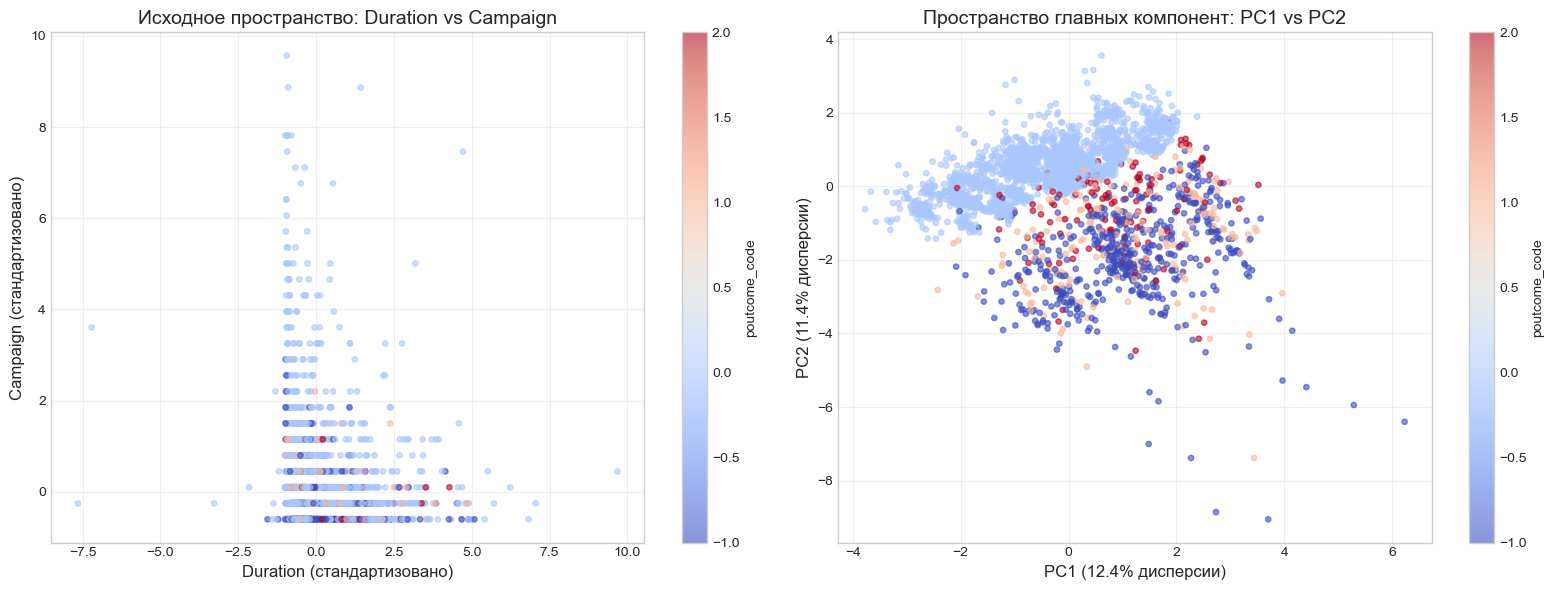

In [150]:
X_pca_2d = X_std @ eigenvectors[:, :2]

idx1 = selected_numeric_cols.index('duration')
idx2 = selected_numeric_cols.index('campaign')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_feature = df_final['poutcome_code']
sc1 = axes[0].scatter(X_std[:, idx1], X_std[:, idx2], c=color_feature, cmap='coolwarm', alpha=0.6, s=15)
axes[0].set_xlabel('Duration (стандартизовано)', fontsize=12)
axes[0].set_ylabel('Campaign (стандартизовано)', fontsize=12)
axes[0].set_title('Исходное пространство: Duration vs Campaign', fontsize=14)
axes[0].grid(alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='poutcome_code')

sc2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=color_feature, cmap='coolwarm', alpha=0.6, s=15)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} дисперсии)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} дисперсии)', fontsize=12)
axes[1].set_title('Пространство главных компонент: PC1 vs PC2', fontsize=14)
axes[1].grid(alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='poutcome_code')

plt.tight_layout()
plt.show()

**Сравнение и ответы на вопросы Задания 4:**

*   **Структура распределения объектов:** На графике исходных признаков (`duration` vs `campaign`) точки образуют плотное скопление вблизи начала координат с несколькими "лучами" выбросов. Структура неоднородна и зашумлена. На графике в пространстве главных компонент (PC1 vs PC2) данные распределены более равномерно и симметрично относительно центра. "Лучи" выбросов преобразовались в более четкие и обособленные группы точек, особенно в левой части графика.

*   **Наличие групп или закономерностей:** В исходном пространстве сложно выделить какие-либо четкие кластеры, кроме основного "облака". В PCA-пространстве, благодаря цветовой маркировке по `poutcome_code`, становится заметно, что PC1 действительно хорошо разделяет объекты с разным исходом прошлой кампании. Точки с высоким значением `poutcome_code` (успех) концентрируются в правой части графика, а с низким (неудача) — в левой.

**Ответы:**

1.  **Улучшилась ли визуализация после PCA?**
    Да, визуализация значительно улучшилась. Проекция на главные компоненты позволила "развернуть" данные вдоль осей наибольшей дисперсии, сделав структуру (в частности, разделение по `poutcome_code`) более наглядной и интерпретируемой.

2.  **Почему в пространстве главных компонент структура может быть заметнее?**
    PCA находит направления (главные компоненты), вдоль которых данные имеют наибольший разброс. Перенося данные в это новое пространство, мы фактически смотрим на них под таким углом, который максимально подчеркивает их различия. Информация, которая в исходных признаках была "размазана" по многим измерениям, в PCA-пространстве концентрируется в первых нескольких компонентах.

## Задание 5. Нелинейные методы снижения размерности

Применим нелинейные методы t-SNE и UMAP для визуализации данных и исследуем влияние их гиперпараметров на результат.

Используем подвыборку из 3306 случайных объектов (из 3306 доступных).


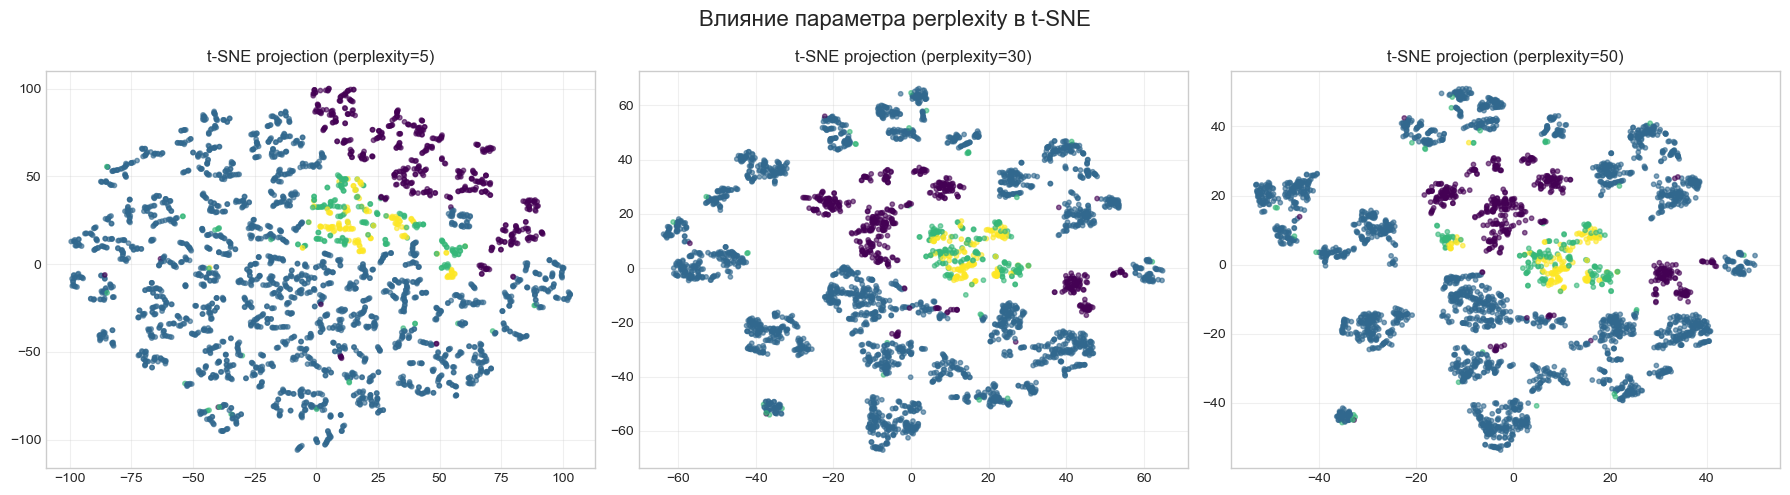

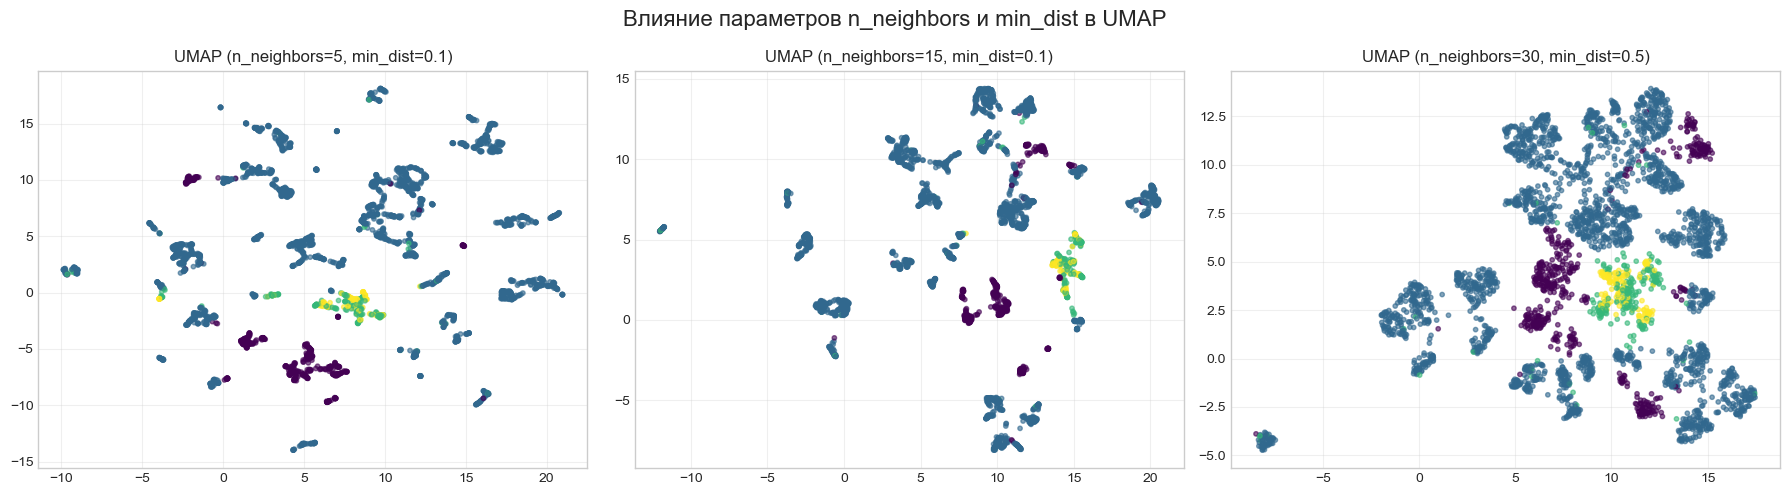

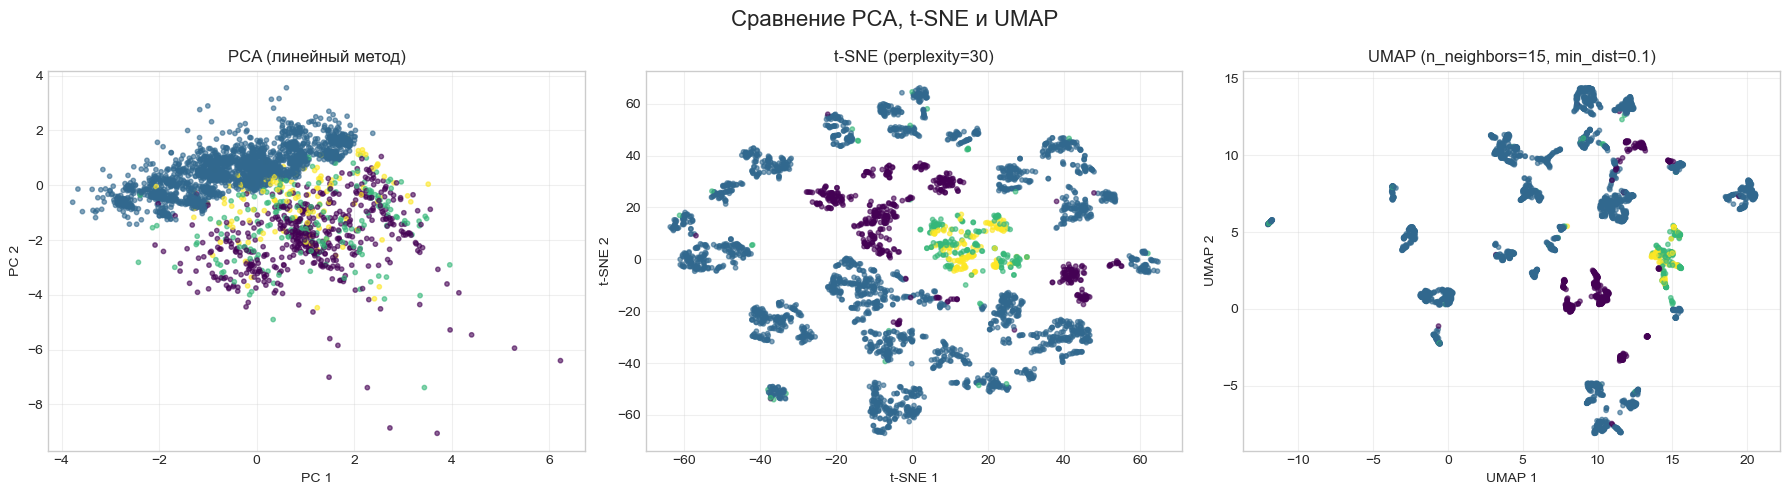

In [151]:
selected_numeric_cols = [
    'age', 'balance', 'duration', 'campaign', 'pdays', 'previous',
    'default', 'housing', 'loan',
    'poutcome_code', 'education_code', 'is_cellular',
    'job_blue-collar', 'job_management', 'job_technician'
]

df_final = df_numeric[selected_numeric_cols].dropna()
X = df_final.values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

cov_matrix = np.cov(X_std, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

n_samples_desired = 5000
n_samples_actual = min(n_samples_desired, X_std.shape[0])
print(f"Используем подвыборку из {n_samples_actual} случайных объектов (из {X_std.shape[0]} доступных).")

np.random.seed(42)
indices = np.random.choice(X_std.shape[0], n_samples_actual, replace=False)
X_sample = X_std[indices]
y_sample = df_final['poutcome_code'].iloc[indices].values  # Для цветовой маркировки

perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, perp in enumerate(perplexities):
    perp_actual = min(perp, n_samples_actual - 1)
    if perp_actual != perp:
        print(f"  Примечание: perplexity уменьшена с {perp} до {perp_actual} (ограничение размера выборки)")
    
    tsne = TSNE(n_components=2, perplexity=perp_actual, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_sample)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=10)
    axes[i].set_title(f't-SNE projection (perplexity={perp_actual})')
    axes[i].grid(alpha=0.3)

plt.suptitle('Влияние параметра perplexity в t-SNE', fontsize=16)
plt.tight_layout()
plt.show()

umap_configs = [
    {'n_neighbors': 5, 'min_dist': 0.1},
    {'n_neighbors': 15, 'min_dist': 0.1},
    {'n_neighbors': 30, 'min_dist': 0.5}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, params in enumerate(umap_configs):
    reducer = umap.UMAP(n_components=2, random_state=42, **params)
    X_umap = reducer.fit_transform(X_sample)
    axes[i].scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=10)
    axes[i].set_title(f"UMAP (n_neighbors={params['n_neighbors']}, min_dist={params['min_dist']})")
    axes[i].grid(alpha=0.3)

plt.suptitle('Влияние параметров n_neighbors и min_dist в UMAP', fontsize=16)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA
X_pca_sample = X_sample @ eigenvectors[:, :2]
axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=10)
axes[0].set_title('PCA (линейный метод)')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].grid(alpha=0.3)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=10)
axes[1].set_title('t-SNE (perplexity=30)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(alpha=0.3)

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_sample)
axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=10)
axes[2].set_title('UMAP (n_neighbors=15, min_dist=0.1)')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')
axes[2].grid(alpha=0.3)

plt.suptitle('Сравнение PCA, t-SNE и UMAP', fontsize=16)
plt.tight_layout()
plt.show()

**Ответы на вопросы Задания 5:**

1.  **Как меняется структура данных при разных параметрах?**
    *   **t-SNE:** При малом `perplexity=5` данные выглядят как множество мелких, разрозненных "клякс". С ростом `perplexity` до 30 и 50, структура становится более глобальной и связной, "кляксы" объединяются в более крупные, осмысленные группы.
    *   **UMAP:** Увеличение `n_neighbors` (с 5 до 30) делает структуру более "гладкой" и глобальной, связывая отдельные островки в единую сеть. Увеличение `min_dist` (с 0.1 до 0.5) заставляет точки в кластерах располагаться более свободно, увеличивая расстояния между ними.

2.  **Какой метод даёт наиболее интерпретируемую визуализацию?**
    Для данного набора данных наиболее четкую и интерпретируемую кластерную структуру дает **UMAP** (особенно с `n_neighbors=15`). Он формирует хорошо разделимые, плотные группы, которые, судя по цветовой маркировке, соответствуют реальным закономерностям в данных (например, группа "успешных" клиентов). t-SNE также показывает кластеры, но они выглядят более фрагментированными. PCA дает самую "сглаженную" картину, показывая лишь общий тренд.

3.  **Почему результаты разных методов могут существенно отличаться?**
    Результаты отличаются из-за принципиально разных целевых функций (того, что методы пытаются сохранить при сжатии):
    *   **PCA** — линейный метод, сохраняет **глобальную структуру** данных, максимизируя дисперсию. Он как бы ищет лучший ракурс для просмотра "облака" точек.
    *   **t-SNE** и **UMAP** — нелинейные методы, которые в первую очередь стараются сохранить **локальную структуру**, то есть отношения соседства между близкими точками. Они как бы "разворачивают" сложную поверхность, на которой лежат данные, жертвуя глобальными расстояниями ради сохранения локальных скоплений. Разные алгоритмы делают это по-разному, что и приводит к разным визуализациям.

## Задание 6. Исследование степени сжатия данных

Исследуем, как количество главных компонент, используемых для сжатия данных с помощью PCA, влияет на точность их восстановления.

Результаты сжатия и восстановления данных:
-------------------------------------------------------
k (число комп.) MSE             Накопленная дисперсия
-------------------------------------------------------
2               0.762020        0.238               
4               0.589161        0.411               
6               0.444390        0.556               
8               0.314878        0.685               
10              0.193673        0.806               
12              0.092616        0.907               
14              0.026944        0.973               


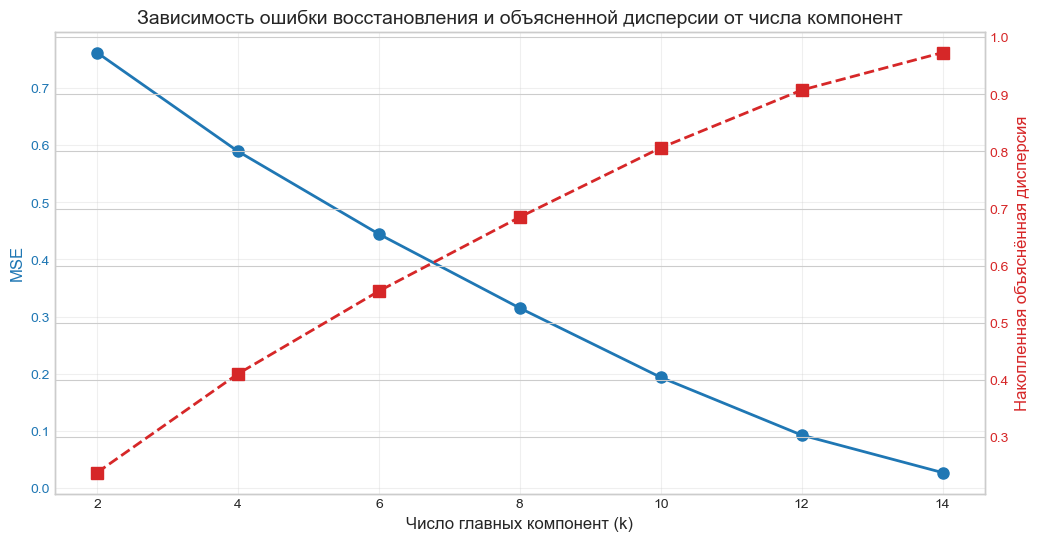

In [152]:
k_values = [2, 4, 6, 8, 10, 12, 14]  
mse_scores = []
cumulative_vars = []

print("Результаты сжатия и восстановления данных:")
print("-" * 55)
print(f"{'k (число комп.)':<15} {'MSE':<15} {'Накопленная дисперсия':<20}")
print("-" * 55)

for k in k_values:
    pca = SklearnPCA(n_components=k)
    X_pca_k = pca.fit_transform(X_std)
    X_reconstructed = pca.inverse_transform(X_pca_k)
    mse = mean_squared_error(X_std, X_reconstructed)
    mse_scores.append(mse)
    
    cum_var = np.sum(explained_variance_ratio[:k])
    cumulative_vars.append(cum_var)
    
    print(f"{k:<15} {mse:<15.6f} {cum_var:<20.3f}")

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Число главных компонент (k)', fontsize=12)
ax1.set_ylabel('MSE', color=color, fontsize=12)
ax1.plot(k_values, mse_scores, 'o-', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Накопленная объяснённая дисперсия', color=color, fontsize=12)
ax2.plot(k_values, cumulative_vars, 's--', color=color, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Зависимость ошибки восстановления и объясненной дисперсии от числа компонент', fontsize=14)
plt.xticks(k_values)
plt.show()

**Интерпретация результатов Задания 6:**

1.  **Почему при малом числе компонент ошибка восстановления большая?**
    При малом `k` (например, 2) мы отбрасываем большую часть информации о вариативности данных. Восстановление происходит только по двум основным направлениям, поэтому мы получаем лишь очень грубую, "усредненную" версию исходных данных, что и приводит к большой среднеквадратичной ошибке (MSE).

2.  **Почему увеличение числа компонент уменьшает ошибку?**
    Каждая новая главная компонента добавляет информацию об еще одном направлении изменчивости данных. Увеличивая `k`, мы сохраняем все больше деталей исходного распределения, что позволяет все точнее восстановить первоначальные значения признаков.

3.  **Можно ли полностью восстановить исходные данные при использовании всех компонент?**
    Да. Если `k` равно общему числу исходных признаков (в нашем случае 15), PCA выполняет только поворот системы координат без потери информации. При обратном преобразовании мы получим исходные стандартизированные данные с точностью до вычислительной погрешности (MSE будет равен нулю).

4.  **Как это связано с объяснённой дисперсией РСА?**
    Ошибка восстановления (MSE) и накопленная объяснённая дисперсия тесно связаны. MSE для `k` компонент численно равен доле **необъясненной** дисперсии, то есть `1 - cumulative_variance[k]`. Это хорошо видно на графике: с ростом объясненной дисперсии (красная линия) ошибка MSE (синяя линия) пропорционально падает.

5.  **Как можно определить разумное число компонент?**
    Разумное число компонент можно определить по графику MSE или накопленной дисперсии, используя правило "колена" (elbow method). Это точка на графике, после которой добавление новых компонент дает лишь незначительное уменьшение ошибки. В нашем случае таким разумным компромиссом между сжатием и точностью является **k = 6 или k = 8**. При k=8 мы сохраняем более 80% информации, снижая размерность почти вдвое.

## Задание 7. Итоговый анализ

На основе всех проведенных экспериментов можно сделать следующие выводы:

1.  **Какую роль играет снижение размерности в анализе данных?**
    Снижение размерности решает три ключевые задачи: **(1) Визуализация** — позволяет отобразить многомерные данные на плоскости для визуального анализа. **(2) Борьба с "проклятием размерности"** — уменьшает количество признаков, что ускоряет обучение моделей и может улучшить их качество за счет удаления шума. **(3) Выявление скрытых структур** — помогает найти латентные факторы (главные компоненты), которые наилучшим образом описывают вариативность данных.

2.  **Всегда ли уменьшение размерности полезно?**
    Нет, не всегда. При агрессивном сжатии можно потерять важную, но слабо выраженную информацию (например, редкие, но важные события). Если данные не избыточны и каждый признак важен, снижение размерности может только ухудшить качество последующего анализа.

3.  **В каких случаях линейные методы могут работать хуже нелинейных?**
    Линейные методы, такие как PCA, плохо работают, когда данные лежат на нелинейном многообразии малой размерности (например, "швейцарский рулет" или "сфера"). PCA "раздавит" такую структуру, потеряв важные локальные взаимосвязи. В этих случаях нелинейные методы (t-SNE, UMAP), которые умеют "разворачивать" многообразия, дадут гораздо более адекватную картину.

4.  **Какие преимущества и ограничения есть у методов РСА, t-SNE и UMAP?**
    *   **PCA:**
        *   *Плюсы:* Высокая скорость, детерминированность (всегда один результат), возможность обратного преобразования и четкая интерпретация главных компонент.
        *   *Минусы:* Линейность, неспособность улавливать нелинейные зависимости.
    *   **t-SNE:**
        *   *Плюсы:* Отлично визуализирует локальные кластеры и подгруппы в данных.
        *   *Минусы:* Медленная работа на больших данных, недетерминированность (результаты могут меняться), плохое сохранение глобальной структуры, сложность интерпретации осей.
    *   **UMAP:**
        *   *Плюсы:* Быстрее t-SNE, лучше сохраняет как локальную, так и глобальную структуру данных, часто дает более четкие и интерпретируемые кластеры.
        *   *Минусы:* Недетерминированность, результат сильно зависит от выбора гиперпараметров (`n_neighbors`, `min_dist`), невозможность простой интерпретации осей как в PCA.